In [1]:
"""
Galaxy Morphology Analysis: Ellipticity-Surface Brightness Correlation
====================================================================
This code analyzes the correlation between galaxy ellipticity and surface brightness
following Xu & Randall 2020. It processes simulation data and compares with observations
of Local Group dwarf spheroidal galaxies.
"""

import os
import sys
import warnings
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import traceback
import pickle
import galaxy_ellipse_collection as gec
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional
import time
from typing import Optional, Dict, List
from collections import defaultdict
TIMING_DATA = defaultdict(list)
ENABLE_TIMING = True

warnings.filterwarnings("ignore")

# ===========================
# Configuration and Setup
# ===========================

import sys
from config import db_connection, sys_path, xu_output_dir
os.environ['TANGOS_DB_CONNECTION'] = db_connection
os.environ['TANGOS_PROPERTY_MODULES'] = 'mytangosproperty'
sys.path.append(sys_path)
import tangos

import mytangosproperty
from galaxy_ellipse_collection import random_viewing_angles, interpolate_orientations

# Physical constants
MASS_TO_LIGHT_THRESHOLD = 85  # M_sun/L_sun threshold for bright/dim classification

# Analysis parameters
N_ITERATIONS = 10000  # Number of Monte Carlo iterations
MIN_STAR_PARTICLES = 10000  # Minimum star particles for analysis

# Output directory
OUTPUT_DIR = xu_output_dir
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)



In [2]:
xu_output_dir

'/home/bk639/OverLeaf/InferencePaper/CorrelationTestingFIRE2/'

In [3]:
# ===========================
# Data Structures
# ===========================

@dataclass
class GalaxyData:
    """Container for all galaxy properties"""
    simulation: str
    halo_id: str
    stellar_mass: float
    dynamical_mass: float
    mass_to_light: float
    half_light_radius: float
    environment: str  # 'central', 'satellite', 'backsplash'
    ellipticity_interpolator: callable
    surface_brightness_interpolator: callable
    shape_b_over_a: callable  # 3D shape parameter b/a
    shape_c_over_a: callable  # 3D shape parameter c/a

@dataclass
class ObservationData:
    """Container for observational comparison data"""
    name: str
    correlation: float
    error: float
    color: str
    label: str

# ===========================
# Utility Functions
# ===========================

def calculate_correlation(ellipticity: np.ndarray, surface_brightness: np.ndarray) -> float:
    """
    Calculate Pearson correlation coefficient between ellipticity and surface brightness.

    Parameters:
    -----------
    ellipticity : array-like
        Galaxy ellipticity values (1 - b/a)
    surface_brightness : array-like
        Surface brightness values

    Returns:
    --------
    float : Correlation coefficient
    """
    if not isinstance(ellipticity, np.ndarray):
        ellipticity = np.array(ellipticity)
    if not isinstance(surface_brightness, np.ndarray):
        surface_brightness = np.array(surface_brightness)

    # Remove NaN values
    mask = np.isfinite(ellipticity) & np.isfinite(surface_brightness)
    if np.sum(mask) < 3:  # Need at least 3 points for meaningful correlation
        return np.nan

    ell_clean = ellipticity[mask]
    sb_clean = surface_brightness[mask]

    numerator = np.sum((ell_clean - np.mean(ell_clean)) * (sb_clean - np.mean(sb_clean)))
    denominator = np.sqrt(np.sum((ell_clean - np.mean(ell_clean))**2) *
                         np.sum((sb_clean - np.mean(sb_clean))**2))

    return numerator / denominator if denominator != 0 else np.nan

def calculate_triaxiality(b_over_a: float, c_over_a: float) -> float:
    """
    Calculate triaxiality parameter T_s.

    T_s = (1 - b²/a²) / (1 - c²/a²)
    T_s < 1/3: oblate
    1/3 < T_s < 2/3: triaxial
    T_s > 2/3: prolate
    """
    return (1 - b_over_a**2) / (1 - c_over_a**2)

def extract_single_value(value):
    """Extract scalar value from potentially nested data structures"""
    if isinstance(value, list):
        return value[0]
    return float(value)

def load_observational_data(xu_folder: str) -> Tuple[ObservationData, ...]:
    """Load Xu & Randall 2020 observational comparison data"""
    # Define observation categories
    obs_data = [
        ObservationData("All LG Dsphs", -0.287, 0.058, '#7B0B01', 'All LG Dsphs'),
        ObservationData("LG Bright", -0.353, 0.059, '#FFCC99',
                       'LG Dsphs\n$M/L<100M_\\odot/L_\\odot$'),
        ObservationData("LG Dim", 0.509, 0.309, '#339AFE',
                       'LG Dsphs\n$M/L>100M_\\odot/L_\\odot$'),
        ObservationData("FIRE", -0.322, 0.213, '#411B52', 'FIRE Simulations')
    ]

    # Load FIRE simulation data
    fire_data = pd.read_csv(os.path.join(xu_folder, 'Data/BasicData/FIRE_Data.csv'))

    # Load scatter plot data
    xu_dim = pd.read_csv(os.path.join(xu_folder, 'Data/BasicData/Xu_Scatter_Dim.csv'))
    xu_bright = pd.read_csv(os.path.join(xu_folder, 'Data/BasicData/Xu_Scatter_Bright.csv'))

    return obs_data, fire_data, xu_dim, xu_bright


def SB_integrated(r_bins, profile_lum_den_v):
    """
    Integrate luminosity density profile to get total luminosity.

    Parameters:
    -----------
    r_bins : array
        Radial bin edges
    profile_lum_den_v : array
        Luminosity density in each bin

    Returns:
    --------
    total_lum : float
        Total integrated luminosity
    """
    # Add 0 at the beginning of r_bins to include the innermost bin
    r_bins_extended = np.insert(r_bins, 0, 0)

    # Calculate annular area for each bin
    # Area of annulus = π * (r_outer² - r_inner²)
    r_inner = r_bins_extended[:-1]
    r_outer = r_bins_extended[1:]


    areas = np.pi * (r_outer**2 - r_inner**2)

    #remove nans
    nanmask = np.isnan(profile_lum_den_v)
    profile_lum_den_v = profile_lum_den_v[~nanmask]
    areas = areas[~nanmask]

    # Total luminosity = sum of (luminosity density × area)
    total_lum = np.sum(profile_lum_den_v * areas)

    return total_lum

# ===========================
# Data Loading Functions
# ===========================

def load_galaxy_data() -> List[GalaxyData]:
    """
    Load all galaxy data from Tangos database and ellipse files.

    Returns:
    --------
    List[GalaxyData] : List of galaxy data objects
    """
    print("Loading galaxy data from Tangos database...")

    # Load ellipse data from pickle file
    with open('ellipse_data_v_stars.pickle', 'rb') as f:
        ellipse_dict = pickle.load(f)
        #print(ellipse_dict)

    # Get all simulations from Tangos
    sims = tangos.all_simulations()
    print(f"Found {len(sims)} simulations")

    galaxy_list = []

    for sim in sims:
        sim_name = str(sim.basename)
        print(f"Processing simulation {sim_name}")

        # Get the latest timestep
        timestep = sim.timesteps[-1] if len(sim.timesteps) > 1 else sim.timesteps[0]
        halos = timestep.halos[:20]  # Limit for testing

        for halo in halos:
            #check if halo is in ellipse_dict
            halo_name = halo.basename
            halo_ref = f'{sim_name}/%/{halo_name}'
            #make sure halo has a readable stellar mass before adding
            if halo['finder_star_mass'] <= 0:
                #print(f'invalid stellar mass: {halo_name}')
                continue
            #check if halo exists in ellipse_dict
            if not halo_ref in ellipse_dict[sim_name]:
                #print(f"Skipping halo {halo_name} - no ellipse data")
                continue
            print(f"Processing halo {halo.halo_number} ({halo_name})")

            try:
                #time halo processing in minutes

                galaxy = process_halo(halo, sim, ellipse_dict)
                if galaxy:
                    galaxy_list.append(galaxy)
                #break
            except Exception as e:
                print(f"Error processing halo {halo.halo_number}: {str(e)}")
                traceback.print_exc()
        #break

    print(f"Successfully loaded {len(galaxy_list)} galaxies")
    return galaxy_list

import time
from typing import Optional, Dict

def process_halo(halo, sim, ellipse_dict: dict) -> Optional[GalaxyData]:
    """Process a single halo and extract all relevant data"""
    # Initialize timing dictionary
    timings = {}
    total_start = time.time()

    # Basic setup
    setup_start = time.time()
    sim_name = str(sim.basename)
    halo_id = str(halo.halo_number)
    halo_ref = f'{sim_name}/%/{halo.basename}'
    timings['setup'] = time.time() - setup_start

    check_start = time.time()
    # Check star particle count
    if 'n_star' in halo.keys() and halo['n_star'][0] < MIN_STAR_PARTICLES:
        return None
    timings['validation_checks'] = time.time() - check_start

    # Load ellipse data
    ellipse_start = time.time()
    halo_ellipse_data = gec.load_and_process_halo_data(sim.basename, halo_ref)
    timings['load_ellipse_data'] = time.time() - ellipse_start

    # Extract masses
    mass_start = time.time()
    stellar_mass = halo.get('finder_star_mass')
    dynamical_mass = extract_single_value(halo.get('Mdyn', 0))
    virial_mass = halo.get('finder_star_mass') + halo.get('finder_gas_mass') + halo.get('finder_dm_mass')

    # Get half-light radius
    half_light_radius = halo.get('Rhalf_v', 0)
    timings['extract_masses'] = time.time() - mass_start

    # Calculate mass-to-light ratio (using face-on orientation)
    ml_start = time.time()
    mass_to_light = calculate_mass_to_light_ratio(halo, dynamical_mass)
    timings['mass_to_light_ratio'] = time.time() - ml_start

    # Create interpolation functions for ellipticity and surface brightness
    interp_start = time.time()
    ellipticity_interpolator, sb_interpolator = create_interpolators(
        halo, halo_ellipse_data
    )
    timings['create_interpolators'] = time.time() - interp_start

    # Get 3D shape functions
    shape_start = time.time()
    shape_b_over_a = halo.calculate('ba_s_smoothed()')
    shape_c_over_a = halo.calculate('ca_s_smoothed()')
    timings['3d_shape_functions'] = time.time() - shape_start

    # Determine environment (will be updated later from external file)
    environment = 'unknown'

    # Create galaxy data object
    create_start = time.time()
    galaxy_data = GalaxyData(
        simulation=sim_name,
        halo_id=halo_id,
        stellar_mass=stellar_mass,
        dynamical_mass=dynamical_mass,
        mass_to_light=mass_to_light,
        half_light_radius=half_light_radius,
        environment=environment,
        ellipticity_interpolator=ellipticity_interpolator,
        surface_brightness_interpolator=sb_interpolator,
        shape_b_over_a=shape_b_over_a,
        shape_c_over_a=shape_c_over_a
    )
    timings['create_object'] = time.time() - create_start

    # Total time
    timings['total'] = time.time() - total_start

    # # Print timing report
    # print(f"\nTiming for halo {halo_id} in {sim_name}:")
    # print("-" * 50)
    #
    # # Sort by time taken (descending)
    # sorted_timings = sorted(timings.items(), key=lambda x: x[1], reverse=True)
    #
    # for step_name, duration in sorted_timings:
    #     percentage = (duration / timings['total']) * 100 if timings['total'] > 0 else 0
    #     print(f"{step_name:25s}: {duration:7.4f}s ({percentage:5.1f}%)")
    #
    # # Identify bottlenecks (steps taking more than 20% of total time)
    # print("\nBottlenecks (>20% of total time):")
    # for step_name, duration in sorted_timings:
    #     percentage = (duration / timings['total']) * 100 if timings['total'] > 0 else 0
    #     if percentage > 20 and step_name != 'total':
    #         print(f"  - {step_name}: {percentage:.1f}%")

    return galaxy_data


def calculate_mass_to_light_ratio(halo, dynamical_mass: float) -> float:
    """Calculate M/L ratio for face-on orientation"""

    #where does this come from?
    # check jordan's code

    if 'profile_mags_v' not in halo.keys() or 'profile_rbins_v' not in halo.keys():
        return np.nan

    # Get face-on data (index 0)
    mags = halo['profile_mags_v'][0]
    rbins = halo['profile_rbins_v'][0]
    reff = halo['image_reffs_v'][0]

    # Find index closest to effective radius
    ind_eff = np.argmin(np.abs(reff - rbins))

    # Calculate luminosity within effective radius
    luminosities = 10**(0.4 * (4.8 - mags))
    lum_eff = np.sum(luminosities[:ind_eff+1])

    return dynamical_mass / lum_eff if lum_eff > 0 else np.nan

def create_interpolators(halo, halo_ellipse_data) -> Tuple[callable, callable]:
    """Create interpolation functions for ellipticity and surface brightness"""
    orientations = halo['image_orientations_v']

    # Create ellipticity data dict
    ellipse_data_dict = {}
    for i, orientation in enumerate(orientations):
        # Use 2Reff data (index 0)
        ellipse_data_dict[orientation] = [halo_ellipse_data[orientation][0]]

    # Create surface brightness data dict
    sb_data_dict = {}
    #total luminosity at face-on orientation (not significantly different from any other orientation)
    total_lum = SB_integrated(halo['profile_rbins_v'][0],halo['profile_v_lum_den'][0]) #should exchange this for actual pynbody luminosity, but this should work as a test
    print(f'total_lum = {total_lum}')
    for i, orientation in enumerate(orientations):
        # Calculate central surface brightness
        if 'profile_mags_v' in halo.keys() and 'profile_binarea_v' in halo.keys():
            mag0 = halo['profile_mags_v'][i][0]
            area0 = halo['profile_binarea_v'][i][0]
            sigma0 = (10**(0.4 * (4.8 - mag0))) / area0 / total_lum #normalize to total lum
            sb_data_dict[orientation] = [sigma0]

    # Create interpolation functions
    ellipticity_func, _ = gec.interpolate_orientations(
        ellipse_data_dict, reff_multipliers=[2]
    )
    sb_func, _ = gec.interpolate_orientations(
        sb_data_dict, reff_multipliers=[2]
    )

    return ellipticity_func, sb_func

def load_environment_classifications(galaxy_list: List[GalaxyData]) -> None:
    """Load environment classifications from external files"""
    # Create mapping for quick lookup
    galaxy_dict = {(g.simulation, g.halo_id): g for g in galaxy_list}

    # Read environment files
    env_files = [
        '/home/bk639/MorphologyMeasurements/Data/BasicData/HaloTypes.BWMDC.txt',
        # '/home/bk639/MorphologyMeasurements/Data/BasicData/HaloTypes.MerianCDM.txt'
    ]

    for file_path in env_files:
        with open(file_path) as f:
            lines = f.readlines()

        for line in lines[1:]:  # Skip header
            parts = line.strip().split('\t')
            if len(parts) < 3:
                continue

            sim_short = parts[0]
            halo_id = parts[1]
            env_type = parts[-2]

            # Find matching galaxy
            for galaxy in galaxy_list:
                if sim_short in galaxy.simulation and galaxy.halo_id == halo_id:
                    if env_type == 'Central':
                        galaxy.environment = 'central'
                    elif env_type == 'Satellite':
                        galaxy.environment = 'satellite'
                    break

    # Mark all 'r' simulations as centrals
    for galaxy in galaxy_list:
        if galaxy.simulation.startswith('r') and not galaxy.simulation.startswith('rogue'):
            galaxy.environment = 'central'

# ===========================
# Analysis Functions
# ===========================

def generate_random_observations(galaxy_list: List[GalaxyData],
                               n_samples: int = 1,
                               sample_size: Optional[int] = None,
                               with_replacement: bool = False) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Generate random viewing angles and calculate properties for galaxies.

    Parameters:
    -----------
    galaxy_list : List[GalaxyData]
        List of all available galaxies
    n_samples : int
        Number of viewing angles per galaxy (default: 1)
    sample_size : Optional[int]
        Number of galaxies to randomly select. If None, use all galaxies.
        Set to 14 to match Xu observational sample size.
    with_replacement : bool
        Whether to sample galaxies with replacement (default: False)

    Returns:
    --------
    ellipticities : array of shape (n_selected_galaxies * n_samples,)
    surface_brightnesses : array of shape (n_selected_galaxies * n_samples,)
    stellar_masses : array of shape (n_selected_galaxies * n_samples,)
    """

    # Assert that if with_replacement is True, that the number of galaxies exceeds sample_size
    if sample_size:
        if with_replacement:
            print(f'Sample size ({sample_size}) requested, but galaxy list has ({len(galaxy_list)}) galaxies')
        else:
            assert len(galaxy_list) >= sample_size, "Number of galaxies cannot be less than target sample size with replacement set to False"

    # Determine which galaxies to use
    if sample_size is None:
        # Use all galaxies
        selected_galaxies = galaxy_list
    else:
        # Randomly sample galaxies
        if with_replacement:
            print(len(galaxy_list), sample_size)
            indices = np.random.choice(len(galaxy_list), size=sample_size, replace=True)
        else:
            # Without replacement - sample_size can't exceed available galaxies
            actual_size = min(sample_size, len(galaxy_list))
            indices = np.random.choice(len(galaxy_list), size=actual_size, replace=False)
        selected_galaxies = [galaxy_list[i] for i in indices]

    # Initialize as lists to concatenate viewing angles
    ellipticities = []
    surface_brightnesses = []
    stellar_masses = []

    for galaxy in selected_galaxies:
        # Generate random viewing angles
        X, Y = random_viewing_angles(n_samples)
        #print(X,Y)

        # Calculate properties at each random orientation
        for i in range(n_samples):
            ell = galaxy.ellipticity_interpolator(X[i], Y[i])
            sb = galaxy.surface_brightness_interpolator(X[i], Y[i])

            ellipticities.append(ell)
            surface_brightnesses.append(sb)
            stellar_masses.append(galaxy.stellar_mass)

    return np.array(ellipticities), np.log10(np.array(surface_brightnesses)), np.array(stellar_masses)

def plot_sb_ell_iterations(plot_data, key, n_iterations):
    """
    Plot surface brightness vs ellipticity for each iteration with linear regression

    Parameters:
    -----------
    plot_data : dict
        Dictionary containing 'ell' and 'sb' arrays for each iteration
    key : str
        The category key to plot
    n_iterations : int
        Number of iterations
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    # Generate colors for each iteration
    colors = plt.cm.viridis(np.linspace(0, 1, n_iterations))

    for i in range(n_iterations):
        ell = plot_data[key]['ell'][i]
        sb = plot_data[key]['sb'][i]
        corr = calculate_correlation(ell, sb)

        # Calculate correlation coefficient
        r = np.corrcoef(sb, ell)[0, 1]

        # Fit linear regression
        slope, intercept, r_value, p_value, std_err = stats.linregress(sb, ell)

        # Plot scatter points
        ax.scatter(sb, ell, alpha=0.5, s=20, color=colors[i],
                   label=f'Iter {i+1} (r={r:.3f}), corr={corr:.3f}')

        # Plot regression line
        x_fit = np.array([np.min(sb), np.max(sb)])
        y_fit = slope * x_fit + intercept
        ax.plot(x_fit, y_fit, color=colors[i], linewidth=2, alpha=0.7)

    ax.set_ylabel('Ellipticity', fontsize=12)
    ax.set_xlabel('Central Surface Brightness (mag/pc²)', fontsize=12)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

    plt.tight_layout()
    return fig, ax

def calculate_correlation_distributions(galaxy_list: List[GalaxyData],
                                      n_iterations: int = 1000,
                                      match_xu_sample_size: bool = True) -> Dict[str, np.ndarray]:
    """
    Calculate correlation distributions for different galaxy subsets using Monte Carlo.

    Parameters:
    -----------
    galaxy_list : List[GalaxyData]
        List of all available galaxies
    n_iterations : int
        Number of Monte Carlo iterations
    match_xu_sample_size : bool
        If True, randomly sample 14 galaxies per iteration to match Xu et al. sample

    Returns:
    --------
    Dictionary with correlation distributions for each subset
    """
    results = {
        'all': np.zeros(n_iterations),
        # 'central': np.zeros(n_iterations),
        # 'satellite': np.zeros(n_iterations),
        # 'bright': np.zeros(n_iterations),
        # 'dim': np.zeros(n_iterations),
        # 'disky': np.zeros(n_iterations),
        # 'non_disky': np.zeros(n_iterations),
        # 'low_mass': np.zeros(n_iterations),
        # 'medium_mass': np.zeros(n_iterations),
        # 'high_mass': np.zeros(n_iterations),
        # 'prolate': np.zeros(n_iterations),
        # 'triaxial': np.zeros(n_iterations),
        # 'oblate': np.zeros(n_iterations),
    }


    # Xu et al. FIRE sample size
    XU_SAMPLE_SIZE = 20

    # Pre-calculate galaxy classifications
    central_mask = np.array([g.environment == 'central' for g in galaxy_list])
    satellite_mask = np.array([g.environment == 'satellite' for g in galaxy_list])
    bright_mask = np.array([g.mass_to_light < MASS_TO_LIGHT_THRESHOLD for g in galaxy_list])
    dim_mask = np.array([g.mass_to_light >= MASS_TO_LIGHT_THRESHOLD for g in galaxy_list])

    # add new catogry based on stellar mass. split into 3 bins, low, medium, high with equal number of galaxies in each bin
    stellar_masses = np.array([g.stellar_mass for g in galaxy_list])
    sorted_indices = np.argsort(stellar_masses)
    n_galaxies = len(galaxy_list)
    low_bin_size = n_galaxies // 3
    medium_bin_size = n_galaxies // 3
    high_bin_size = n_galaxies - low_bin_size - medium_bin_size
    low_mask = np.zeros(n_galaxies, dtype=bool)
    medium_mask = np.zeros(n_galaxies, dtype=bool)
    high_mask = np.zeros(n_galaxies, dtype=bool)
    #find threshold indices and masses
    low_threshold_index = sorted_indices[low_bin_size - 1] if low_bin_size > 0 else n_galaxies
    hi_threshold_index = sorted_indices[low_bin_size + medium_bin_size - 1] if medium_bin_size > 0 else n_galaxies
    low_threshold_mass = stellar_masses[low_threshold_index] if low_bin_size > 0 else np.inf
    hi_threshold_mass = stellar_masses[hi_threshold_index] if medium_bin_size > 0 else np.inf
    for i, galaxy in enumerate(galaxy_list):
        if galaxy.stellar_mass < low_threshold_mass:
            low_mask[i] = True
        elif galaxy.stellar_mass > hi_threshold_mass:
            high_mask[i] = True
        elif low_threshold_mass <= galaxy.stellar_mass <= hi_threshold_mass:
            medium_mask[i] = True
    #print mass range for each mass category
    print(stellar_masses)
    min_mass = np.min(stellar_masses)
    print(f"Low mass range: {min_mass:.2e} - {low_threshold_mass:.2e} M_sun")
    print(f"Medium mass range: {low_threshold_mass:.2e} - {hi_threshold_mass:.2e} M_sun")
    max_mass = np.max(stellar_masses)
    print(f"High mass range: {hi_threshold_mass:.2e} - {max_mass:.2e} M_sun")

    oblate_mask = np.zeros(len(galaxy_list), dtype=bool)
    triaxial_mask = np.zeros(len(galaxy_list), dtype=bool)
    prolate_mask = np.zeros(len(galaxy_list), dtype=bool)

    # Classify disky galaxies (b/a > 0.65 and c/a < 0.35 at 2*Reff)
    disky_mask = np.zeros(len(galaxy_list), dtype=bool)
    for i, galaxy in enumerate(galaxy_list):
        b = galaxy.shape_b_over_a(2 * galaxy.half_light_radius)
        c = galaxy.shape_c_over_a(2 * galaxy.half_light_radius)
        disky_mask[i] = (b > 0.65 and c < 0.35)
        # Classify shape regimes
        t = calculate_triaxiality(b, c)
        if t < 1/3:
            prolate_mask[i] = True
        elif t > 2/3:
            oblate_mask[i] = True
        else:
            triaxial_mask[i] = True



    # Define bar status at timestep 4096 based on your data
    barred_at_4096 = {568, 571}  # Galaxies with bars at timestep 4096
    non_barred_at_4096 = {431, 492, 515, 634, 642, 442, 523, 544, 569, 597, 613, 614, 656, 718, 719, 741, 886, 916, 918}  # Galaxies without bars at 4096 (includes N/A entries)

    # Function to extract galaxy ID from simulation name
    def extract_galaxy_id(simulation_name):
        # Extract number after 'r' in simulation name (e.g., 'r555' -> 555)
        import re
        match = re.search(r'r(\d+)', simulation_name)
        return int(match.group(1)) if match else None

    # Create bar-related masks
    barred_mask = []
    non_barred_mask = []
    bar_unknown_mask = []

    for galaxy in galaxy_list:
        galaxy_id = extract_galaxy_id(galaxy.simulation)

        if galaxy_id in barred_at_4096:
            barred_mask.append(True)
            non_barred_mask.append(False)
            bar_unknown_mask.append(False)
        elif galaxy_id in non_barred_at_4096:
            barred_mask.append(False)
            non_barred_mask.append(True)
            bar_unknown_mask.append(False)
        else:
            # Galaxy not in your table - treat as unknown
            barred_mask.append(False)
            non_barred_mask.append(False)
            bar_unknown_mask.append(True)

    # Create subset lists for more efficient sampling
    central_galaxies = [g for i, g in enumerate(galaxy_list) if central_mask[i]]
    satellite_galaxies = [g for i, g in enumerate(galaxy_list) if satellite_mask[i]]
    bright_galaxies = [g for i, g in enumerate(galaxy_list) if bright_mask[i]]
    dim_galaxies = [g for i, g in enumerate(galaxy_list) if dim_mask[i]]
    disky_galaxies = [g for i, g in enumerate(galaxy_list) if disky_mask[i]]
    non_disky_galaxies = [g for i, g in enumerate(galaxy_list) if not disky_mask[i]]
    low_mass_galaxies = [g for i, g in enumerate(galaxy_list) if low_mask[i]]
    medium_mass_galaxies = [g for i, g in enumerate(galaxy_list) if medium_mask[i]]
    high_mass_galaxies = [g for i, g in enumerate(galaxy_list) if high_mask[i]]
    prolate_galaxies = [g for i, g in enumerate(galaxy_list) if prolate_mask[i]]
    triaxial_galaxies = [g for i, g in enumerate(galaxy_list) if triaxial_mask[i]]
    oblate_galaxies = [g for i, g in enumerate(galaxy_list) if oblate_mask[i]]

    # Bar-related galaxy lists
    barred_galaxies = [g for i, g in enumerate(galaxy_list) if barred_mask[i]]
    non_barred_galaxies = [g for i, g in enumerate(galaxy_list) if non_barred_mask[i]]
    bar_unknown_galaxies = [g for i, g in enumerate(galaxy_list) if bar_unknown_mask[i]]

    # Place into a dictionary for easy access with keys matching the results keys
    categorized_galaxies = {
        'all': galaxy_list,
        'central': central_galaxies,
        'satellite': satellite_galaxies,
        'bright': bright_galaxies,
        'dim': dim_galaxies,
        'disky': disky_galaxies,
        'non_disky': non_disky_galaxies,
        'low_mass': low_mass_galaxies,
        'medium_mass': medium_mass_galaxies,
        'high_mass': high_mass_galaxies,
        'prolate': prolate_galaxies,
        'triaxial': triaxial_galaxies,
        'oblate': oblate_galaxies,
        'barred': barred_galaxies,
        'non_barred': non_barred_galaxies,
        'bar_unknown': bar_unknown_galaxies
    }
    print(f"Running {n_iterations} Monte Carlo iterations...")
    print(f"Total galaxies: {len(galaxy_list)}")
    print(f"Central: {len(central_galaxies)}, Satellite: {len(satellite_galaxies)}")
    print(f"Bright: {len(bright_galaxies)}, Dim: {len(dim_galaxies)}")
    print(f"Disky: {len(disky_galaxies)}, Non-disky: {len(non_disky_galaxies)}")
    # PLOTTING FUNCTION

    min_sb_list = []
    max_sb_list = []
    plot_data = {key: {'ell': [], 'sb': []} for key in results.keys()}

    #categorized_galaxies['all'] = categorized_galaxies['all'][0:3] # TEMPORARY:
    for iteration in range(n_iterations):
        # Print progress every 5%
        prog = (100 * iteration / n_iterations)
        if prog % 5 == 0:
            print(f"Progress ({prog:.1f}%)")


        # Calculate correlations for each category
        for key in results.keys():

            ell,sb,sm = generate_random_observations(
                categorized_galaxies[key], sample_size=None, with_replacement=False
                #categorized_galaxies[key], sample_size=None
            )
            #for each trial keep track of min and max surface brightness
                    # STORE DATA FOR PLOTTING
            plot_data[key]['ell'].append(ell)
            plot_data[key]['sb'].append(sb)
            min_sb_list.append(np.min(sb))
            max_sb_list.append(np.max(sb))
            corr = calculate_correlation(ell,sb)# sb / sm if key != 'bright' else sb)
            results[key][iteration] = corr

    for i in range(len(max_sb_list)):
        print(f"Iteration {i}: min SB = {min_sb_list[i]:.1e}, max SB = {max_sb_list[i]:.1e}, correlation = {results['all'][i]:.3f}")

    #fig, ax = plot_sb_ell_iterations(plot_data, key='all', n_iterations=np.min(10,n_iterations))
    plt.show()

    return results

def calculate_individual_correlations(galaxy_list: List[GalaxyData]) -> Dict[str, List[float]]:
    """
    Calculate correlation for each individual galaxy using all available orientations.

    Returns:
    --------
    Dictionary with correlation values and galaxy properties
    """
    results = {
        'correlations': [],
        'stellar_masses': [],
        'triaxialities': [],
        'environments': [],
        'b_over_a': [],
        'c_over_a': []
    }

    for galaxy in galaxy_list:
        # Sample multiple orientations
        n_samples = 100
        X, Y = random_viewing_angles(n_samples)

        ell = np.array([galaxy.ellipticity_interpolator(X[i], Y[i])
                       for i in range(n_samples)])
        sb = np.array([galaxy.surface_brightness_interpolator(X[i], Y[i])
                      for i in range(n_samples)])

        correlation = calculate_correlation(ell, sb)

        # Calculate shape parameters at effective radius
        b = galaxy.shape_b_over_a(galaxy.half_light_radius)
        c = galaxy.shape_c_over_a(galaxy.half_light_radius)
        triaxiality = calculate_triaxiality(b, c)

        results['correlations'].append(correlation)
        results['stellar_masses'].append(np.log10(galaxy.stellar_mass))
        results['triaxialities'].append(triaxiality)
        results['environments'].append(galaxy.environment)
        results['b_over_a'].append(b)
        results['c_over_a'].append(c)

    return results



In [4]:
# ===========================
# Plotting Functions
# ===========================
def plot_correlation_distribution(correlation_data: Dict[str, np.ndarray],
                                obs_data: List[ObservationData],
                                fire_data: pd.DataFrame,
                                categories_to_plot: List[Dict[str, any]],
                                title: str,
                                output_file: str):
    """
    Plot correlation distribution with observational comparisons.

    Parameters:
    -----------
    correlation_data : dict
        Dictionary with all correlation distributions
    obs_data : list
        Observational comparison data
    fire_data : DataFrame
        FIRE simulation data
    categories_to_plot : list of dicts
        Each dict should have:
        - 'key': key in correlation_data
        - 'label': label for legend
        - 'color': color for plotting
        - 'linestyle': line style (default: '-')
        - 'linewidth': line width (default: 3)
    title : str
        Plot title
    output_file : str
        Output file path
    """
    fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    # Set up axes
    ax.set_xlabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.tick_params(which='both', labelsize=15)
    ax.set_xlim([-1, 1])

    # Plot observational data
    for obs in obs_data:
        ax.axvline(obs.correlation, color=obs.color, linewidth=2, label=obs.label)
        ax.axvspan(obs.correlation - obs.error,
                  obs.correlation + obs.error,
                  color=obs.color, alpha=0.3)

    # Plot FIRE data
    if fire_data is not None:
        ax.plot(fire_data['X'], fire_data['Y'],
               color=obs_data[3].color, linewidth=2)
        ax.fill_between(fire_data['X'], [0]*len(fire_data['X']),
                       fire_data['Y'], color=obs_data[3].color, alpha=0.5)

    # Plot simulation distributions for specified categories
    xbins = np.linspace(-1, 1, 500)

    for category in categories_to_plot:
        key = category['key']
        if key not in correlation_data:
            print(f"Warning: '{key}' not found in correlation data")
            continue

        dist = correlation_data[key]
        finite_values = dist[np.isfinite(dist)]

        if len(finite_values) > 0:
            #check if finite_values consists entirely of 0's
            if np.all(finite_values == 0):
                print(f"Warning: '{key}' has all zero values, skipping density plot")
                continue
            density = stats.gaussian_kde(finite_values)
            ax.plot(xbins, density(xbins),
                   color=category.get('color', 'k'),
                   linestyle=category.get('linestyle', '-'),
                   linewidth=category.get('linewidth', 3),
                   label=category['label'])

    ax.set_ylim(bottom=0)
    ax.legend(loc='upper right', prop={'size': 12})
    ax.set_title(title, fontsize=20)

    #plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    #plt.close()



In [5]:


# ===========================
# Main Analysis
# ===========================

#this cell takes a long time, so we will require the user to run it confirmation if data already exists
#check if galaxy_list already exists
if 'galaxy_list' in globals():
    print("Galaxy data already loaded. Skipping loading step.")
else:
    # Load galaxy data
    print("="*60)
    print("Loading galaxy data...")
    print("="*60)
    galaxy_list = load_galaxy_data()
    load_environment_classifications(galaxy_list)

    # Load observational comparison data
    xu_folder = '/home/bk639/MorphologyMeasurements'
    obs_data, fire_data, xu_dim, xu_bright = load_observational_data(xu_folder)

Loading galaxy data...
Loading galaxy data from Tangos database...
Found 6 simulations
Processing simulation m11d_res7100
Processing halo 1 (halo_1)
total_lum = 28950586.898173526
Original points count: 72
reff_index 0 (mult=2): 72 values, 0 NaNs
After filtering reff_index 0: 91 valid values
Original points count: 72
reff_index 0 (mult=2): 72 values, 0 NaNs
After filtering reff_index 0: 91 valid values
Processing halo 2 (halo_2)
total_lum = 2057607.7100471058
Original points count: 72
reff_index 0 (mult=2): 72 values, 0 NaNs
After filtering reff_index 0: 91 valid values
Original points count: 72
reff_index 0 (mult=2): 72 values, 0 NaNs
After filtering reff_index 0: 91 valid values
Processing halo 4 (halo_4)
total_lum = 45202.002369367896
Original points count: 72
reff_index 0 (mult=2): 72 values, 12 NaNs
After filtering reff_index 0: 75 valid values
Original points count: 72
reff_index 0 (mult=2): 72 values, 0 NaNs
After filtering reff_index 0: 91 valid values
Processing simulation m11

In [6]:
len(galaxy_list)

14

In [13]:
!env | grep TANGOS

TANGOS_DB_CONNECTION=/home/bk639/data/test_dbs/FIRE_test.db
TANGOS_PROPERTY_MODULES=mytangosproperty


In [18]:

# Run correlation analysis
print("\n" + "="*60)
print("Running correlation analysis...")
print("="*60)
correlation_distributions = calculate_correlation_distributions(
    galaxy_list, n_iterations=3000
)



Running correlation analysis...
[4.04687466e+09 3.12300441e+08 4.20196655e+07 4.16166374e+07
 1.37810124e+09 9.09614372e+07 3.78939708e+09 9.12456290e+08
 3.39394268e+08 3.87450259e+07 3.43084234e+07 1.43081799e+07
 9.27954899e+06 3.84307999e+06]
Low mass range: 3.84e+06 - 3.43e+07 M_sun
Medium mass range: 3.43e+07 - 9.10e+07 M_sun
High mass range: 9.10e+07 - 4.05e+09 M_sun
Running 3000 Monte Carlo iterations...
Total galaxies: 14
Central: 0, Satellite: 0
Bright: 14, Dim: 0
Disky: 0, Non-disky: 14
Progress (0.0%)
Progress (5.0%)
Progress (10.0%)
Progress (15.0%)
Progress (20.0%)
Progress (25.0%)
Progress (30.0%)
Progress (35.0%)
Progress (40.0%)
Progress (45.0%)
Progress (50.0%)
Progress (55.0%)
Progress (60.0%)
Progress (65.0%)
Progress (70.0%)
Progress (75.0%)
Progress (80.0%)
Progress (85.0%)
Progress (90.0%)
Progress (95.0%)
Iteration 0: min SB = -6.7e+00, max SB = -4.3e+00, correlation = -0.555
Iteration 1: min SB = -7.0e+00, max SB = -4.3e+00, correlation = -0.365
Iteration 2: m

In [15]:
len(galaxy_list)

14

In [16]:
xu_output_dir

'/home/bk639/OverLeaf/InferencePaper/CorrelationTestingFIRE2/'

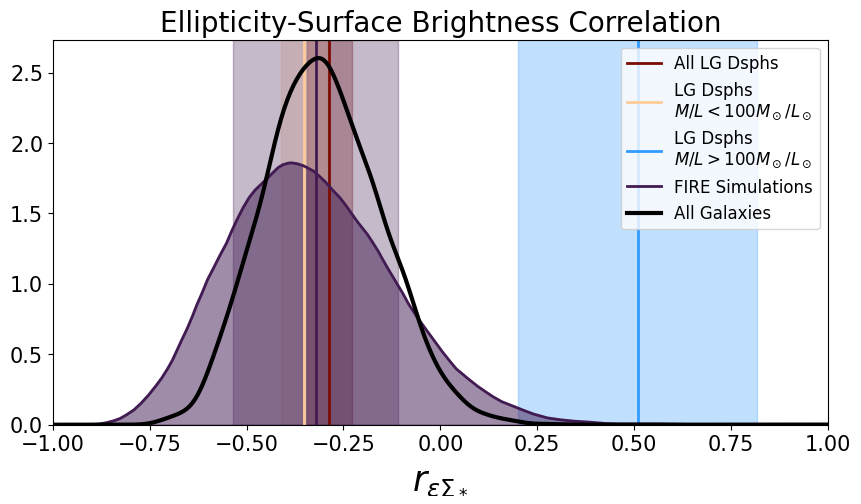

In [19]:

# 1. All galaxies (single category)
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'all', 'label': 'All Galaxies', 'color': 'black', 'linewidth': 3}
    ],
    title="Ellipticity-Surface Brightness Correlation",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_All.png')
)

In [36]:

# 2. Central vs Satellite comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'central', 'label': 'Centrals', 'color': 'blue', 'linestyle': '-'},
        {'key': 'satellite', 'label': 'Satellites', 'color': 'red', 'linestyle': '--'}
    ],
    title="Central vs Satellite Galaxies",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_Environment.png')
)

# 3. Bright vs Dim comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'bright', 'label': r'$M/L<100M_\odot/L_\odot$', 'color': 'goldenrod', 'linestyle': '-'},
        {'key': 'dim', 'label': r'$M/L>100M_\odot/L_\odot$', 'color': 'navy', 'linestyle': '--'}
    ],
    title="Bright vs Dim Galaxies",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_MassToLight.png')
)

# 4. Disky vs Non-disky comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'disky', 'label': 'Disky', 'color': 'green', 'linestyle': '-'},
        {'key': 'non_disky', 'label': 'Non-disky', 'color': 'purple', 'linestyle': '-'}
    ],
    title="Disky vs Non-disky Galaxies",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_Shape.png')
)

# 5. Mass-based comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'low_mass', 'label': 'Low Mass', 'color': 'orange', 'linestyle': '-'},
        {'key': 'medium_mass', 'label': 'Medium Mass', 'color': 'cyan', 'linestyle': '--'},
        {'key': 'high_mass', 'label': 'High Mass', 'color': 'magenta', 'linestyle': '-.'}
    ],
    title="Mass-based Comparison",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_Mass.png')
)


# 6. plot oblate/triaxial/prolate comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'oblate', 'label': 'Oblate', 'color': 'orange', 'linestyle': '-'},
        {'key': 'triaxial', 'label': 'Triaxial', 'color': 'green', 'linestyle': '--'},
        {'key': 'prolate', 'label': 'Prolate', 'color': 'purple', 'linestyle': '-.'}
    ],
    title="Shape Regime Comparison",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_ShapeRegime.png')
)

# Plot bar status comparison
plot_correlation_distribution(
    correlation_distributions,
    obs_data,
    fire_data,
    categories_to_plot=[
        {'key': 'barred', 'label': 'Barred', 'color': 'red', 'linestyle': '-'},
        {'key': 'non_barred', 'label': 'Non-barred', 'color': 'blue', 'linestyle': '--'},
        {'key': 'bar_unknown', 'label': 'Bar Status Unknown', 'color': 'gray', 'linestyle': ':'}
    ],
    title="Bar Status Comparison",
    output_file=os.path.join(OUTPUT_DIR, 'Correlation_BarStatus.png')
)



Calculating individual galaxy correlations...

Summary Statistics
all         : r = -0.301 ± 0.147

Analysis complete!


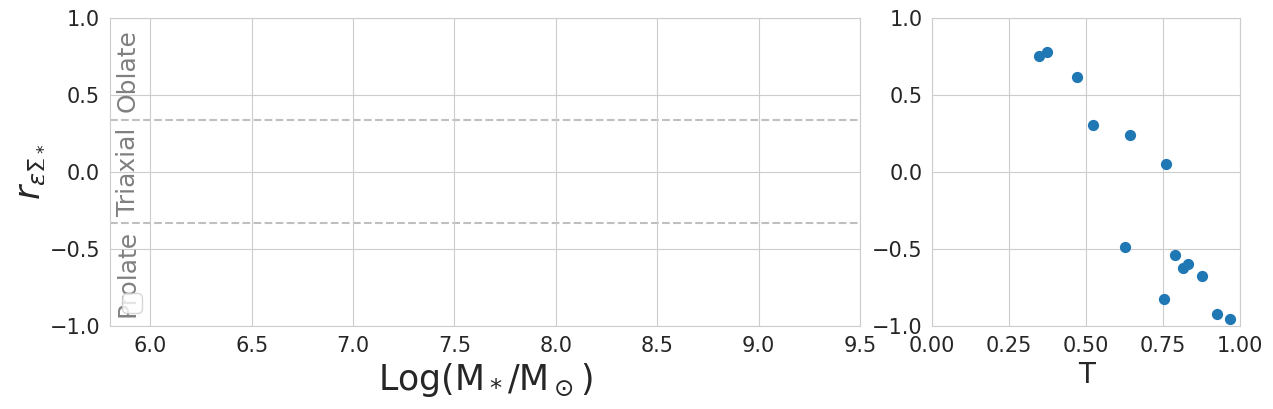

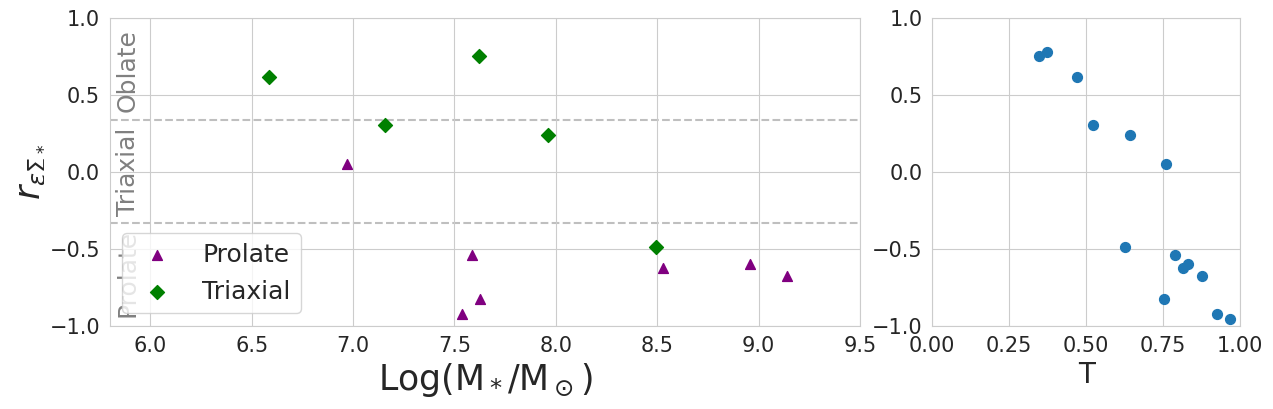

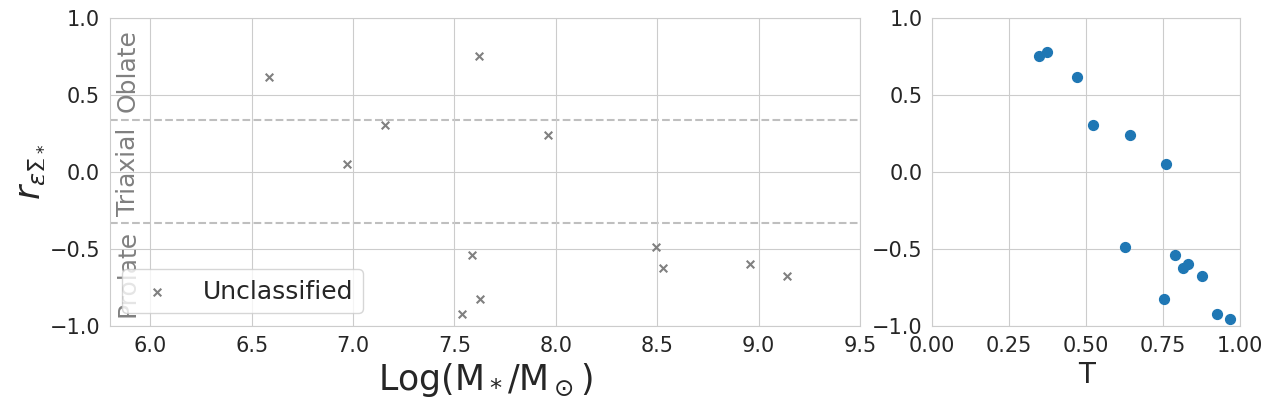

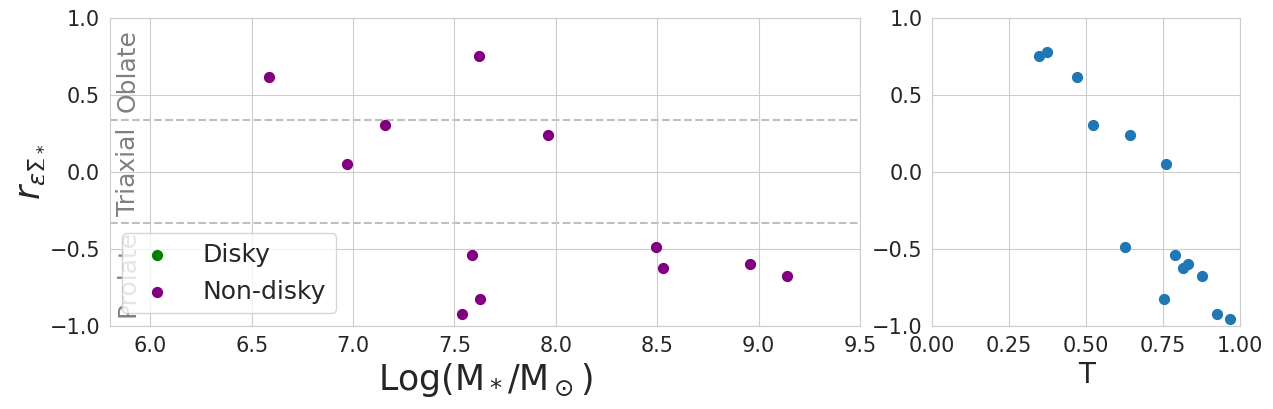

In [37]:
# Plot correlation results for individual galaxies


In [ ]:

# Calculate individual galaxy correlations
print("\n" + "="*60)
print("Calculating individual galaxy correlations...")
print("="*60)
individual_results = calculate_individual_correlations(galaxy_list)


# Print summary statistics
print("\n" + "="*60)
print("Summary Statistics")
print("="*60)
for subset, dist in correlation_distributions.items():
    finite_values = dist[np.isfinite(dist)]
    if len(finite_values) > 0:
        mean_corr = np.mean(finite_values)
        std_corr = np.std(finite_values)
        print(f"{subset:12s}: r = {mean_corr:6.3f} ± {std_corr:5.3f}")

print("\nAnalysis complete!")




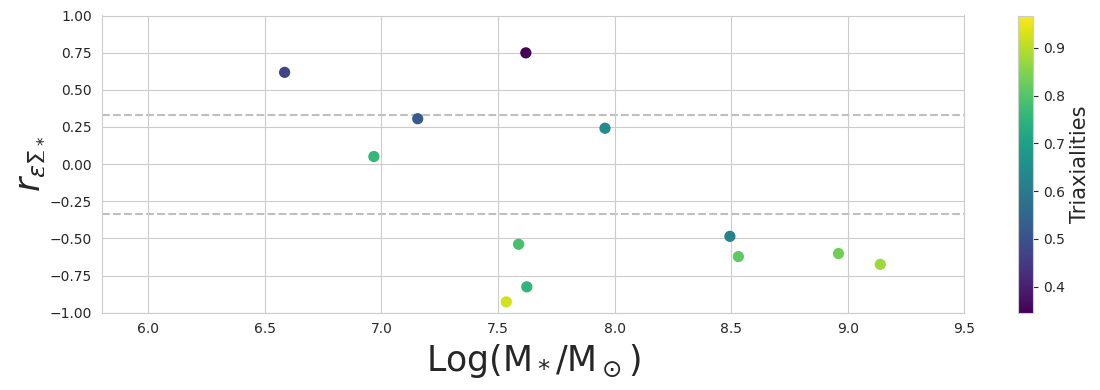

In [38]:

# ===========================
# For correlation vs mass plots
# ===========================
import matplotlib.gridspec as gridspec
def plot_correlation_vs_mass(individual_results: Dict[str, List[float]],
                           categories_to_plot: List[Dict[str, any]],
                           output_file: str):
    """
    Plot correlation vs stellar mass for multiple categories.

    Parameters:
    -----------
    individual_results : dict
        Dictionary with correlation and property data
    categories_to_plot : list of dicts
        Each dict should have:
        - 'mask': boolean array or callable that returns boolean array
        - 'label': label for legend
        - 'color': color for plotting
        - 'marker': marker style (default: 'o')
        - 'size': marker size (default: 50)
    output_file : str
        Output file path
    """

    # Create figure with custom gridspec for different subplot sizes
    fig = plt.figure(figsize=(16, 4))
    gs = gridspec.GridSpec(1, 3, width_ratios=[2, 1, 0.1], hspace=0, wspace=0.1)

    # Create subplots
    ax1 = fig.add_subplot(gs[0, 0])  # Left plot (larger)
    ax2 = fig.add_subplot(gs[0, 1])  # Right plot (smaller, square)

    # Share y-axis between the two plots
    ax2.sharey(ax1)

    correlations = np.array(individual_results['correlations'])
    masses = np.array(individual_results['stellar_masses'])
    environments = individual_results['environments']

    # Left plot
    ax = ax1
    # Plot each category
    for category in categories_to_plot:
        # Get mask
        if callable(category['mask']):
            mask = category['mask'](individual_results)
        else:
            mask = category['mask']

        if np.sum(mask) > 0:
            ax.scatter(masses[mask], correlations[mask],
                      c=category['color'],
                      marker=category.get('marker', 'o'),
                      s=category.get('size', 50),
                      label=category['label'])

    # Add reference lines for shape regimes
    ax.axhline(-1/3, color='0.75', linestyle='--', zorder=0)
    ax.axhline(1/3, color='0.75', linestyle='--', zorder=0)

    # Labels
    ax.set_xlabel(r'Log(M$_*$/M$_\odot$)', fontsize=25)
    ax.set_ylabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.set_xlim([5.8, 9.5])
    ax.set_ylim([-1, 1])
    ax.tick_params(which='both', labelsize=15)

    # Add shape regime labels
    ax.text(5.83, -0.66, 'Prolate', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')
    ax.text(5.83, 0, 'Triaxial', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')
    ax.text(5.83, 0.66, 'Oblate', fontsize=18, rotation='vertical',
           verticalalignment='center', c='0.5')

    ax.legend(loc='lower left', prop={'size': 18})

    # Right plot (smaller and square)
    triaxialities = np.array(individual_results['triaxialities'])
    ax2.scatter(triaxialities, correlations, s=50)

    # Set limits for the right plot
    ax2.set_xlim([0, 1])
    ax2.set_ylim([-1, 1])  # Explicitly set y-limits too

    # Make the right plot truly square
    # For x-range=1 and y-range=2, aspect ratio should be 0.5 for square appearance
    ax2.set_aspect(0.5, adjustable='box')

    ax2.tick_params(which='both', labelsize=15)
    ax2.set_xlabel('T', fontsize=20)

    # Remove y-axis labels from right plot since they're shared
    #ax2.set_yticklabels([])

    plt.tight_layout()
    plt.savefig(output_file, dpi=300)

# Define mask functions for complex selections
def is_bright_central(results):
    """Mask for bright central galaxies"""
    envs = np.array(results['environments'])
    masses = np.array(results['stellar_masses'])
    # Assuming you have mass_to_light in results, otherwise need to add it
    return (envs == 'central') & (masses > 7.0)  # Example condition

def is_dim_satellite(results):
    """Mask for dim satellite galaxies"""
    envs = np.array(results['environments'])
    masses = np.array(results['stellar_masses'])
    return (envs == 'satellite') & (masses < 7.0)

# 1. Simple environment comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': np.array([env == 'central' for env in individual_results['environments']]),
         'label': 'Centrals', 'color': 'blue', 'marker': 'o'},
        {'mask': np.array([env == 'satellite' for env in individual_results['environments']]),
         'label': 'Satellites', 'color': 'red', 'marker': 'v'}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Environment.png')
)

# 2. Shape-based comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': np.array(individual_results['triaxialities']) < 0.33,
         'label': 'Oblate', 'color': 'orange', 'marker': 's'},
        {'mask': np.array(individual_results['triaxialities']) > 0.67,
         'label': 'Prolate', 'color': 'purple', 'marker': '^'},
        {'mask': (np.array(individual_results['triaxialities']) >= 0.33) &
                 (np.array(individual_results['triaxialities']) <= 0.67),
         'label': 'Triaxial', 'color': 'green', 'marker': 'D'}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Shape.png')
)

# 3. Complex multi-category comparison
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': is_bright_central, 'label': 'Bright Centrals', 'color': 'darkblue', 'marker': 'o', 'size': 70},
        {'mask': is_dim_satellite, 'label': 'Dim Satellites', 'color': 'darkred', 'marker': 'v', 'size': 70},
        {'mask': np.array([env == 'unknown' for env in individual_results['environments']]),
         'label': 'Unclassified', 'color': 'gray', 'marker': 'x', 'size': 30}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Complex.png')
)

# disky vs non-disky comparison
def is_disky(results):
    """Mask for disky galaxies"""
    b_over_a = np.array(results['b_over_a'])
    c_over_a = np.array(results['c_over_a'])
    return (b_over_a > 0.65) & (c_over_a < 0.35)

disk_mask = is_disky(individual_results)
nondisk_mask = ~disk_mask
plot_correlation_vs_mass(
    individual_results,
    categories_to_plot=[
        {'mask': disk_mask , 'label': 'Disky', 'color': 'green', 'marker': 'o', 'size': 50},
        {'mask': nondisk_mask, 'label': 'Non-disky', 'color': 'purple', 'marker': 'o', 'size': 50}
    ],
    output_file=os.path.join(OUTPUT_DIR, 'CorrVsMass_Disky.png'))


In [39]:
galaxy_list[40]

2.9714487355811823
3.979904749056142
15.596642025540444
41.98373366260802
2.978596666770064
25.914437259851237
5.4908616744634235
3.437838040928578
8.099277822701712
29.39196999549006
21.721691921097147
20.318894257590962
25.757832427376492
23.787610391147748


In [40]:



# 4. Custom color map based on continuous property
# This requires a slight modification to support colormaps
def plot_correlation_vs_mass_colormap(individual_results, color_property, output_file):
    """Special version that colors by a continuous property"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    #add a second box to the right side of the plot to plot t vs rcorr

    correlations = np.array(individual_results['correlations'])
    masses = np.array(individual_results['stellar_masses'])
    colors = np.array(individual_results[color_property])

    # Create scatter plot with colormap
    scatter = ax.scatter(masses, correlations, c=colors, cmap='viridis', s=50)

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label(color_property.replace('_', ' ').title(), fontsize=15)

    # Rest of the plot setup...
    ax.axhline(-1/3, color='0.75', linestyle='--', zorder=0)
    ax.axhline(1/3, color='0.75', linestyle='--', zorder=0)
    ax.set_xlabel(r'Log(M$_*$/M$_\odot$)', fontsize=25)
    ax.set_ylabel(r'$r_{\epsilon\Sigma_*}$', fontsize=25)
    ax.set_xlim([5.8, 9.5])
    ax.set_ylim([-1, 1])

    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')

# Use it:
plot_correlation_vs_mass_colormap(
    individual_results,
    'triaxialities',
    os.path.join(OUTPUT_DIR, 'CorrVsMass_Triaxiality.png')
)

GalaxyData(simulation='m11d_res7100', halo_id='1', stellar_mass=4046874661.0099015, dynamical_mass=4213792498.5299187, mass_to_light=np.float64(2.9714487355811823), half_light_radius=5.0263275973244586, environment='unknown', ellipticity_interpolator=<function interpolate_orientations.<locals>.interpolate at 0x7fa5711d4680>, surface_brightness_interpolator=<function interpolate_orientations.<locals>.interpolate at 0x7fa5711d4ae0>, shape_b_over_a=<function SmoothAxisRatio.smooth_shape.<locals>.ba_s_func at 0x7fa5711d45e0>, shape_c_over_a=<function SmoothAxisRatio.smooth_shape.<locals>.ca_s_func at 0x7fa571206fc0>)

In [ ]:
for galaxy in galaxy_list:
    print(galaxy.mass_to_light)

In [ ]:
galaxy_list[0]
